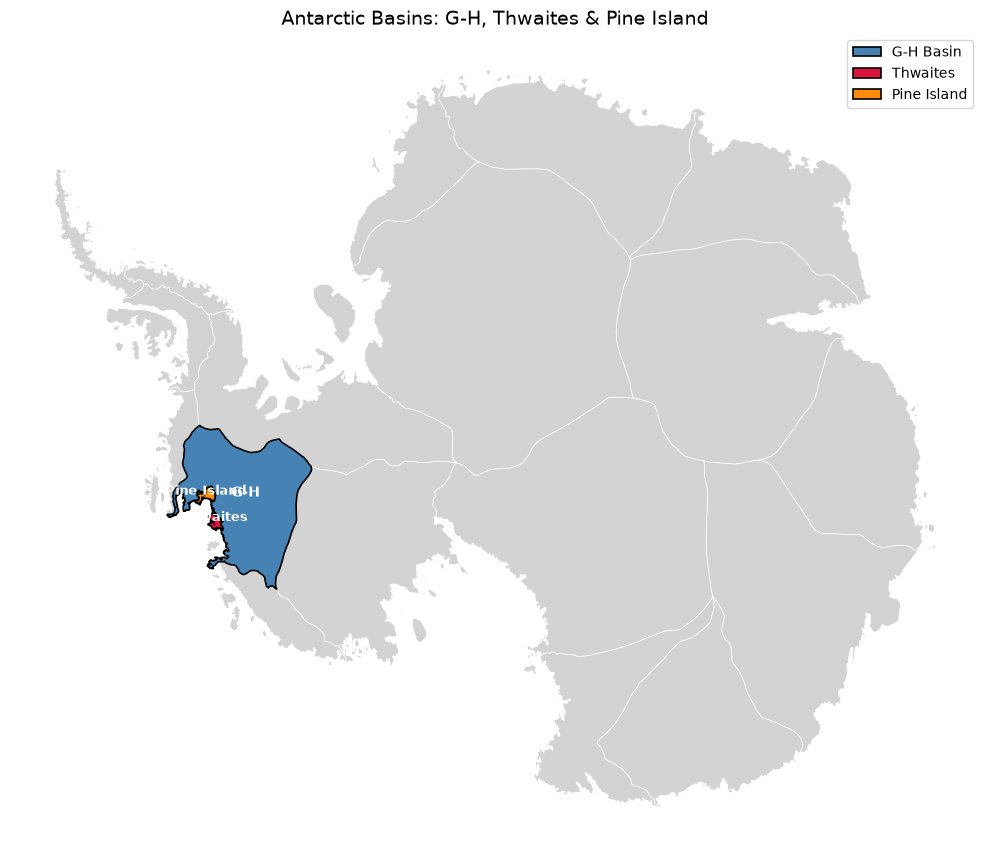

In [19]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

common_data_dir = os.environ.get("COMMON_DATA", "")
base_dir = os.path.join(common_data_dir, "drainage-basins", "MEaSUREs-Antarctic-boundaries-v02")

# Load full shapefiles
basins     = gpd.read_file(os.path.join(base_dir, "Basins_IMBIE_Antarctica_v02.shp"))
iceshelves = gpd.read_file(os.path.join(base_dir, "IceShelf_Antarctica_v02.shp"))

# --- Filter targets ---
gh_basin      = basins[basins["NAME"] == "G-H"]
thwaites      = iceshelves[iceshelves["NAME"].str.contains("Thwaites", case=False)]
pine_island   = iceshelves[iceshelves["NAME"].str.contains("Pine", case=False)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Background: all basins in light gray
basins.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)

# Highlighted features
gh_basin.plot(ax=ax,    color="steelblue",   edgecolor="black", linewidth=1.2, label="G-H Basin")
thwaites.plot(ax=ax,    color="crimson",     edgecolor="black", linewidth=1.2, label="Thwaites")
pine_island.plot(ax=ax, color="darkorange",  edgecolor="black", linewidth=1.2, label="Pine Island")

# Labels at centroid
for _, row in gh_basin.iterrows():
    ax.annotate("G-H", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=10, color="white", fontweight="bold")

for _, row in thwaites.iterrows():
    ax.annotate("Thwaites", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

for _, row in pine_island.iterrows():
    ax.annotate("Pine Island", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Antarctic Basins: G-H, Thwaites & Pine Island", fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figs/antarctic_basins.png")
plt.show()


Boundary shape: (1739, 2)
First few coords (x, y) in meters:
[[-1599824.40361038  -445946.8177648 ]
 [-1598446.89920769  -446930.74948101]
 [-1598053.32652121  -448209.86071208]
 [-1597462.96749149  -449193.79242828]
 [-1596774.21529015  -449488.97194314]]


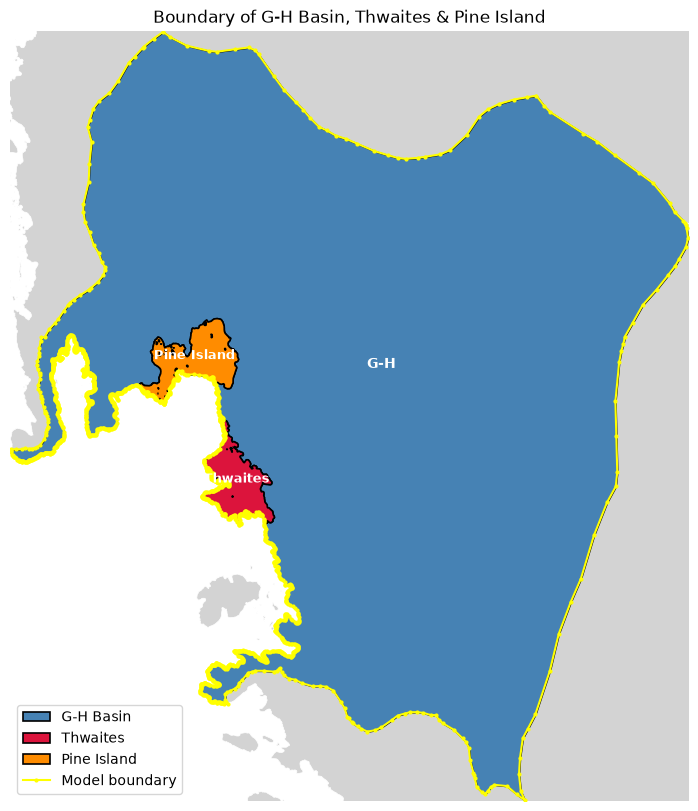

In [33]:
import os
import numpy as np
import geopandas as gpd
from shapely.ops import unary_union

common_data_dir = os.environ.get("COMMON_DATA", "")
base_dir = os.path.join(common_data_dir, "drainage-basins", "MEaSUREs-Antarctic-boundaries-v02")
    
# --- Load shapefiles ---
basins     = gpd.read_file(os.path.join(base_dir, "Basins_IMBIE_Antarctica_v02.shp"))
iceshelves = gpd.read_file(os.path.join(base_dir, "IceShelf_Antarctica_v02.shp"))

# --- Reproject everything to EPSG:3031 (Antarctic Polar Stereographic) ---
basins     = basins.to_crs(epsg=3031)
iceshelves = iceshelves.to_crs(epsg=3031)

# --- Filter the three regions ---
gh_basin    = basins[basins["NAME"] == "G-H"]
thwaites    = iceshelves[iceshelves["NAME"].str.contains("Thwaites", case=False)]
pine_island = iceshelves[iceshelves["NAME"].str.contains("Pine", case=False)]

# --- Merge into one unified polygon ---
combined_geom = unary_union([
    gh_basin.geometry.values[0],
    thwaites.geometry.values[0],
    pine_island.geometry.values[0],
])

# --- Extract exterior boundary coordinates ---
# combined_geom may be a Polygon or MultiPolygon
if combined_geom.geom_type == "Polygon":
    coords = np.array(combined_geom.exterior.coords)  # Nx2

elif combined_geom.geom_type == "MultiPolygon":
    # Take the largest polygon (main landmass, ignore small islands)
    largest = max(combined_geom.geoms, key=lambda g: g.area)
    coords  = np.array(largest.exterior.coords)        # Nx2

print(f"Boundary shape: {coords.shape}")   # e.g. (1842, 2)
print(f"First few coords (x, y) in meters:\n{coords[:5]}")

# --- Optional: save to file ---
np.save("gh_thwaites_pi_boundary_3031.npy", coords)
np.savetxt("gh_thwaites_pi_boundary_3031.csv", coords,
           delimiter=",", header="x_m,y_m", comments="")

# plot the coordinates 

fig, ax = plt.subplots(figsize=(10, 10))

# Background: all basins in light gray
basins.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)

# Highlighted features
gh_basin.plot(ax=ax,    color="steelblue",   edgecolor="black", linewidth=1.2, label="G-H Basin")
thwaites.plot(ax=ax,    color="crimson",     edgecolor="black", linewidth=1.2, label="Thwaites")
pine_island.plot(ax=ax, color="darkorange",  edgecolor="black", linewidth=1.2, label="Pine Island")

# Labels at centroid
for _, row in gh_basin.iterrows():
    ax.annotate("G-H", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=10, color="white", fontweight="bold")

for _, row in thwaites.iterrows():
    ax.annotate("Thwaites", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

for _, row in pine_island.iterrows():
    ax.annotate("Pine Island", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Antarctic Basins: G-H, Thwaites & Pine Island", fontsize=14)
ax.set_axis_off()

ax.set_xlim(coords[:, 0].min() - 1000, coords[:, 0].max() + 1000)
ax.set_ylim(coords[:, 1].min() - 1000, coords[:, 1].max() + 1000)

ax.plot(coords[:, 0], coords[:, 1], '-o', markersize=2, color="yellow", label="Model boundary")
# set y and x limit to the range of the boundary coordinates
ax.legend()
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.set_title("Boundary of G-H Basin, Thwaites & Pine Island")
ax.set_aspect("equal")
ax.grid(True)
plt.savefig("figs/issm_model_boundary.png", dpi=300)
plt.show()

In [39]:
import numpy as np
import os

data_dir = os.environ.get("PROJECT_DATA", "")
exp_dir  = os.path.join(data_dir, "exp-files")

def write_exp(filepath, coords, name="DomainOutline"):
    """Write an ISSM-compatible .exp file. Closes the ring if needed."""
    # Ensure ring is closed
    if not np.allclose(coords[0], coords[-1]):
        coords = np.vstack([coords, coords[0]])

    n = len(coords)   # count AFTER closing — must match what's written

    with open(filepath, "w") as f:
        f.write(f"## Name:{name}\n")
        f.write("## Icon:0\n")
        f.write("# Points Count Value\n")
        f.write(f"{n} 1.000000\n")        # ← count from actual array
        f.write("# X pos Y pos\n")
        for x, y in coords:
            f.write(f"{x} {y}\n")

    print(f"Wrote {n} points → {filepath}")


# Full resolution
write_exp(
    os.path.join(exp_dir, "gh_thwaites_pi_boundary_full.exp"),
    coords
)

# 10% subsampled
coords_10 = coords[::10]
write_exp(
    os.path.join(exp_dir, "gh_thwaites_pi_boundary_subsampled_10perc.exp"),
    coords_10
)

# 20% subsampled
coords_20 = coords[::5]
write_exp(
    os.path.join(exp_dir, "gh_thwaites_pi_boundary_subsampled_20perc.exp"),
    coords_20
)


Wrote 1739 points → /home/donglaiyang/Documents/Georgia-Tech/Research/ASE-perturbed/data/exp-files/gh_thwaites_pi_boundary_full.exp
Wrote 175 points → /home/donglaiyang/Documents/Georgia-Tech/Research/ASE-perturbed/data/exp-files/gh_thwaites_pi_boundary_subsampled_10perc.exp
Wrote 349 points → /home/donglaiyang/Documents/Georgia-Tech/Research/ASE-perturbed/data/exp-files/gh_thwaites_pi_boundary_subsampled_20perc.exp


In [ ]:
import numpy as np
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPoint
from shapely.vectorized import contains  # fast vectorized point-in-polygon

# --- Combined domain geometry (already in EPSG:3031) ---
gh_geom          = gh_basin.geometry.values[0]
thwaites_geom    = thwaites.geometry.values[0]
pine_island_geom = pine_island.geometry.values[0]

combined_geom = gh_geom.union(thwaites_geom).union(pine_island_geom)

# --- Build 200 m grid over bounding box ---
minx, miny, maxx, maxy = combined_geom.bounds
spacing = 1000   # 1000 m spacing

x_grid = np.arange(minx, maxx, spacing)   # 1000 m spacing
y_grid = np.arange(miny, maxy, spacing)   # 1000 m spacing

xx, yy = np.meshgrid(x_grid, y_grid)
xx_flat = xx.ravel()
yy_flat = yy.ravel()

print(f"Total grid points (bounding box): {len(xx_flat):,}")

# --- Step 1: Clip to combined domain (fast vectorized) ---
inside_domain = contains(combined_geom, xx_flat, yy_flat)

x_domain = xx_flat[inside_domain]
y_domain = yy_flat[inside_domain]

print(f"Points inside combined domain   : {len(x_domain):,}")

# --- Step 2: Assign mask (1 = grounded, 0 = floating) ---
inside_gh = contains(gh_geom, x_domain, y_domain)

mask = inside_gh.astype(np.int8)   # 1 = grounded, 0 = floating

print(f"Grounded points (1): {np.sum(mask == 1):,}")
print(f"Floating  points (0): {np.sum(mask == 0):,}")

# --- Step 3: Stack into Nx3 array [x, y, mask] ---
grid_mask = np.column_stack([x_domain, y_domain, mask])

# --- Save ---
mask_dir = os.path.join(data_dir, "masks")

np.save(os.path.join(mask_dir, f"gh_thwaites_pi_grid_mask_{spacing}m.npy"), grid_mask)

np.savetxt(
    os.path.join(mask_dir, f"gh_thwaites_pi_grid_mask_{spacing}m.csv"),
    grid_mask,
    delimiter=",",
    header="x_m,y_m,mask",
    comments=""
)

print(f"Saved grid mask → shape {grid_mask.shape}")



Total grid points (bounding box): 817,587
Points inside combined domain   : 430,973
Grounded points (1): 419,486
Floating  points (0): 11,487


/tmp/ipykernel_45191/274730745.py:29: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  inside_domain = contains(combined_geom, xx_flat, yy_flat)
/tmp/ipykernel_45191/274730745.py:37: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  inside_gh = contains(gh_geom, x_domain, y_domain)


Saved grid mask → shape (430973, 3)


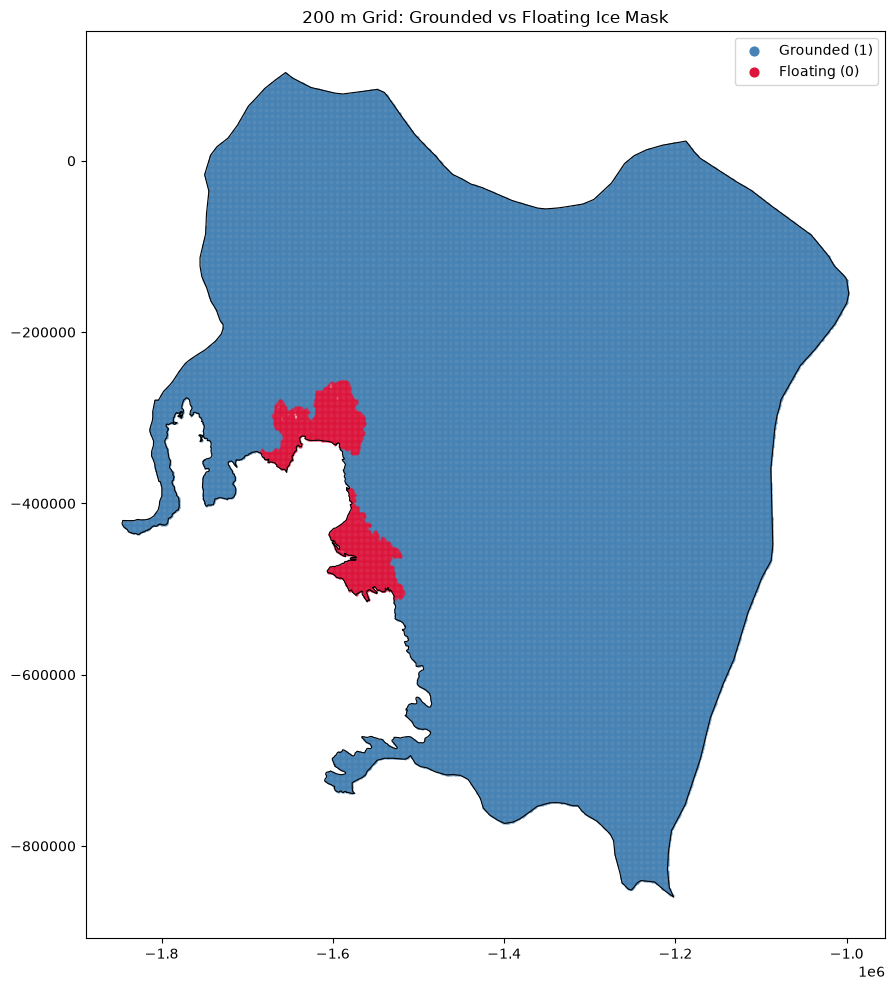

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))

grounded = grid_mask[grid_mask[:, 2] == 1]
floating  = grid_mask[grid_mask[:, 2] == 0]

ax.scatter(grounded[:, 0], grounded[:, 1], s=0.1, c="steelblue", label="Grounded (1)")
ax.scatter(floating[:, 0],  floating[:, 1],  s=0.1, c="crimson",   label="Floating (0)")

# Overlay polygon boundaries for reference
x_b, y_b = combined_geom.exterior.xy
ax.plot(x_b, y_b, "k-", linewidth=0.8)

ax.set_title("200 m Grid: Grounded vs Floating Ice Mask")
ax.set_aspect("equal")
ax.legend(markerscale=20)
plt.tight_layout()
plt.show()
